# Verification Task Report (`test_data.csv`)

This notebook documents the required verification workflow in one place: preprocessing, ensemble construction, contamination choice, and final export checks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_helpers import save_figure, setup_theme

from anomaly_detection.datasets.catalog import FULL_DATASET_SPECS
from anomaly_detection.geometry import distance_concentration_ratio
from anomaly_detection.models import (
    DBSCANModel,
    ECODModel,
    HBOSModel,
    IForestModel,
    LOFModel,
    OCSVMModel,
)
from anomaly_detection.models.params import (
    DBSCANParams,
    ECODParams,
    HBOSParams,
    IForestParams,
    LOFParams,
    OCSVMParams,
)
from anomaly_detection.training.blind_audit import write_blind_audit_json
from anomaly_detection.training.blind_features import prepare_blind_feature_matrix
from anomaly_detection.training.ensemble import consensus_labels, normalize_to_rank, weighted_borda
from anomaly_detection.training.phase5 import (
    DISTANCE_CONCENTRATION_THRESHOLD,
    HIGH_DIMENSION_THRESHOLD,
    STRUCTURAL_DISTANCE_THRESHOLD,
    elbow_contamination_from_scores,
)

setup_theme()

In [2]:
TEST_DATA_PATH = Path("../data/test_data.csv")
TEST_LABELS_PATH = Path("../data/test_labels.csv")
PROFILE_JSON_PATH = Path("../data/test_data_profile.json")

if not TEST_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing file: {TEST_DATA_PATH}")

raw = pd.read_csv(TEST_DATA_PATH)
write_blind_audit_json(raw, PROFILE_JSON_PATH)
X = prepare_blind_feature_matrix(raw)

n_rows, n_features = X.shape
cr = float(distance_concentration_ratio(X, pool_max_rows=None))

print("rows:", n_rows)
print("features after preprocessing:", n_features)
print("distance concentration ratio:", round(cr, 6))
print("profile json:", PROFILE_JSON_PATH)

rows: 3443
features after preprocessing: 22
distance concentration ratio: 1.335538
profile json: ../data/test_data_profile.json


## Contamination Estimate Strategy

I estimate contamination from nearest ODDS profiles in `(n, d)` space, with elbow fallback when structural mismatch is high.

In [3]:
odds_specs = [spec for spec in FULL_DATASET_SPECS if "/" not in spec.dataset_id]
rows_ref = np.array([float(s.expected_rows) for s in odds_specs], dtype=float)
feat_ref = np.array([float(s.expected_dim) for s in odds_specs], dtype=float)

sigma_r = max(float(np.std(rows_ref)), 1.0)
sigma_f = max(float(np.std(feat_ref)), 1.0)


def profile_distance(spec):
    return float(
        np.hypot(
            (n_rows - float(spec.expected_rows)) / sigma_r,
            (n_features - float(spec.expected_dim)) / sigma_f,
        )
    )


nearest = sorted(odds_specs, key=lambda s: (profile_distance(s), s.dataset_id))[:3]
c_odds = float(np.mean([s.contamination for s in nearest]))
nearest_distance = float(profile_distance(nearest[0]))

pd.DataFrame(
    {
        "dataset": [s.dataset_id for s in nearest],
        "expected_rows": [s.expected_rows for s in nearest],
        "expected_dim": [s.expected_dim for s in nearest],
        "contamination": [s.contamination for s in nearest],
        "distance": [profile_distance(s) for s in nearest],
    }
)

,dataset,expected_rows,expected_dim,contamination,distance
0,cardio,1831,21,0.096,0.017345
1,lympho,148,18,0.041,0.051636
2,pendigits,6870,16,0.023,0.071503


## Ensemble and Parameters

I use six detectors, convert raw scores to rank space, and aggregate with weighted Borda. Weights are adjusted only when dimensionality or distance concentration suggests distance-based fragility.

In [4]:
models = {
    "OCSVM": OCSVMModel(params=OCSVMParams()),
    "IForest": IForestModel(params=IForestParams(n_jobs=-1)),
    "LOF": LOFModel(params=LOFParams(n_jobs=-1)),
    "DBSCAN": DBSCANModel(params=DBSCANParams(n_jobs=-1)),
    "ECOD": ECODModel(params=ECODParams()),
    "HBOS": HBOSModel(params=HBOSParams()),
}

ranked = {}
for name, model in models.items():
    model.fit(X)
    ranked[name] = normalize_to_rank(model.score_samples(X))

if n_features > HIGH_DIMENSION_THRESHOLD or cr < DISTANCE_CONCENTRATION_THRESHOLD:
    weights = {
        "OCSVM": 0.5,
        "LOF": 0.5,
        "DBSCAN": 0.5,
        "IForest": 1.0,
        "ECOD": 1.5,
        "HBOS": 1.5,
    }
else:
    weights = dict.fromkeys(models, 1.0)

ensemble_score = weighted_borda(ranked, weights=weights)

if nearest_distance > STRUCTURAL_DISTANCE_THRESHOLD:
    c_hat = float(elbow_contamination_from_scores(ensemble_score))
    c_source = "elbow"
else:
    c_hat = c_odds
    c_source = "nearest_odds"

c_eff = float(np.clip(c_hat, max(15.0 / float(max(n_rows, 1)), 1e-6), 0.489))
labels = consensus_labels(
    ranked_scores=ranked, ensemble_score=ensemble_score, contamination_estimate=c_eff
)

summary = pd.DataFrame(
    {
        "metric": [
            "c_odds",
            "nearest_distance",
            "c_hat_raw",
            "c_eff_used",
            "c_source",
            "outliers_count",
            "outliers_ratio",
        ],
        "value": [
            c_odds,
            nearest_distance,
            c_hat,
            c_eff,
            c_source,
            int(labels.sum()),
            float(labels.mean()),
        ],
    }
)
summary

,metric,value
0,c_odds,0.053333
1,nearest_distance,0.017345
2,c_hat_raw,0.053333
3,c_eff_used,0.053333
4,c_source,nearest_odds
5,outliers_count,263
6,outliers_ratio,0.076387


PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/verification_task_score_and_agreement.png')

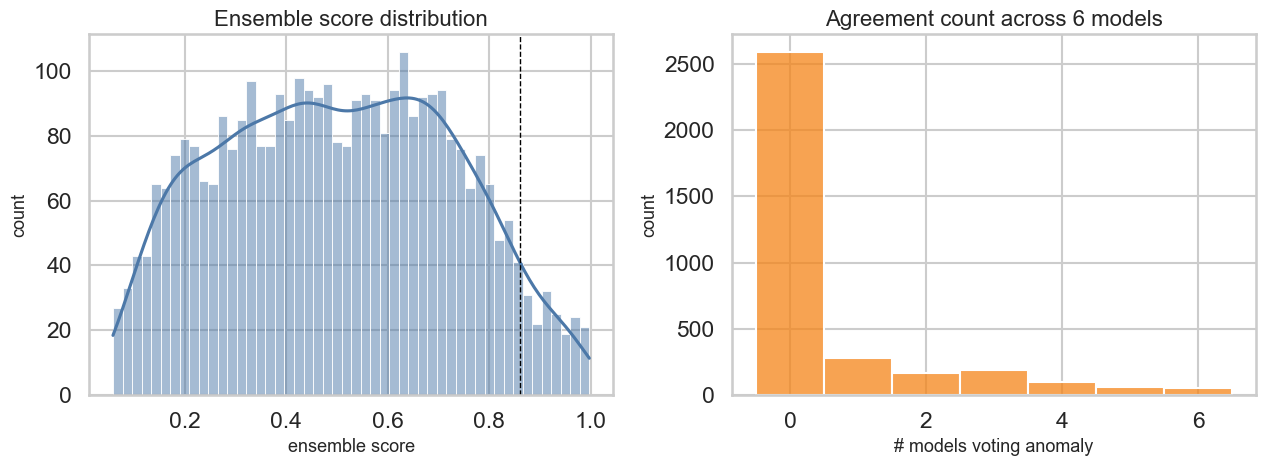

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(ensemble_score, bins=50, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(
    np.percentile(ensemble_score, 100 * (1 - c_eff)), linestyle="--", color="black", linewidth=1
)
axes[0].set_title("Ensemble score distribution")
axes[0].set_xlabel("ensemble score")
axes[0].set_ylabel("count")

agreement = np.zeros(n_rows, dtype=int)
cutoff = 1.0 - min(2.0 * c_eff, 0.999)
for arr in ranked.values():
    agreement += (arr > cutoff).astype(int)

sns.histplot(agreement, bins=np.arange(-0.5, 6.6, 1.0), ax=axes[1], color="#F58518")
axes[1].set_title("Agreement count across 6 models")
axes[1].set_xlabel("# models voting anomaly")
axes[1].set_ylabel("count")

plt.tight_layout()
# annotate_figure(
#     fig,
#     "Verification task: rank-based ensemble, contamination from nearest-ODDS or elbow fallback.",
# )
save_figure("verification_task_score_and_agreement.png")

## Export `test_labels.csv`

This cell writes the required file and enforces assignment constraints (`class` column, binary ints, correct row count, no index).

In [6]:
output = pd.DataFrame({"class": labels.astype(int)})
output.to_csv(TEST_LABELS_PATH, index=False)

assert output.columns.tolist() == ["class"]
assert set(output["class"].unique()).issubset({0, 1})
assert len(output) == len(raw)

print("saved:", TEST_LABELS_PATH)
print("outliers:", int(output["class"].sum()))
print("ratio:", float(output["class"].mean()))

saved: ../data/test_labels.csv
outliers: 263
ratio: 0.07638687191402846


## Concise Justification

Short narrative summary for the report: why preprocessing, why rank aggregation, why this contamination policy, and why the final export is valid.